# CUSTOMER CHURN

El dataset Customer Churn.csv contiene un conjunto de datos de una compañía de telecomunicaciones iraní. 

Cada fila representa un cliente a lo largo de un año. Además de la etiqueta de clase (abandono/no abandono), 
se incluye información sobre la actividad de los clientes, como las llamadas fallidas y la duración de la suscripción.

Descripción de las variables del conjunto de datos:
* Call Failure – number of call failures
* Complaints – binary (0: No complaint, 1: complaint)
* Subscription Length – total months of subscription
* Charge Amount – ordinal attribute (0: lowest amount, 9: highest amount)
* Seconds of Use total – seconds of calls
* Frequency of use – total number of calls
* Frequency of SMS – total number of text messages
* Distinct Called Numbers – total number of distinct phone calls
* Age Group – ordinal attribute (1: younger age, 5: older age)
* Tariff Plan – binary (1: Pay as you go, 2: contractual)
* Status – binary (1: active, 2: non-active)
* Age - age of customer
* Customer Value – the calculated value of customer
* Churn – class label (1: churn, 0: non-churn)

In [19]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Transformacion
from sklearn.preprocessing import PowerTransformer

# Winsorizer
!pip install -q feature_engine
from feature_engine.outliers import Winsorizer

# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Balanceo
from sklearn.utils import resample

# Metricas
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error,confusion_matrix, classification_report, accuracy_score
import shap
shap.initjs()
%matplotlib inline
from statsmodels.stats.weightstats import ttest_ind
from sklearn.base import is_classifier, is_regressor

# Train split
from sklearn.model_selection import train_test_split, cross_val_score

# Regresion
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor

# Arboles
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text

# Regularización
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# SVC
from sklearn.svm import SVC

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Importancia predictores
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE

# Busqueda de hiperparametros por Grid Search
from sklearn.model_selection import GridSearchCV

# Shap
import shap
shap.initjs()
from shap import LinearExplainer

# Ensamble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import VotingRegressor

In [20]:
# Dataset
datos = pd.read_csv('data/Customer Churn.csv')
datos.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,FN,FP,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,177.8760,69.7640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,41.4315,60.0000,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,1382.8680,203.6520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,216.0180,74.0020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,131.2245,64.5805,0


# Exploracion

In [21]:
# Forma del dataframe
print(f"Filas: {datos.shape[0]} \nColumnas: {datos.shape[1]}")

Filas: 3150 
Columnas: 16


In [26]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  FN                       3150 non-null   float64
 14  FP                      

In [25]:
datos.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,FN,FP,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,423.875624,98.304688,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,465.313890,50.724492,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000,60.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,102.421125,61.380125,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,205.632000,72.848000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,709.549875,128.838875,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1948.752000,266.528000,1.000000


In [27]:
datos.nunique()

Call  Failure                37
Complains                     2
Subscription  Length         45
Charge  Amount               11
Seconds of Use             1756
Frequency of use            242
Frequency of SMS            405
Distinct Called Numbers      92
Age Group                     5
Tariff Plan                   2
Status                        2
Age                           5
Customer Value             2654
FN                         2654
FP                         2195
Churn                         2
dtype: int64

# Preprocesamiento

In [28]:
# Duplicados
duplicados = datos[datos.duplicated()]
print(f"Filas duplicadas encontradas: {duplicados.shape[0]}")

Filas duplicadas encontradas: 300


In [30]:
data = datos.drop_duplicates().reset_index(drop=True)
print(f"Shape después de eliminar duplicados: {data.shape}")

Shape después de eliminar duplicados: (2850, 16)


In [31]:
# Separo entre numerico continuo y "categorico"

# Variables categóricas (binarias u ordinales con pocas categorías)
categoricas = ['Complains', 'Charge Amount', 'Age Group', 'Tariff Plan', 'Status', 'Churn']

# Variables continuas (números reales con muchas posibles escalas)
continuas = ['Call Failure', 'Subscription Length', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age', 'Customer Value', 'FN', 'FP']

categoricas_existentes = [col for col in categoricas if col in data.columns]
continuas_existentes = [col for col in continuas if col in data.columns]

cat_data = data[categoricas_existentes]
num_data = data[continuas_existentes]

In [32]:
cat_data.head()

,Complains,Age Group,Tariff Plan,Status,Churn
0,0,3,1,1,0
1,0,2,1,2,0
2,0,3,1,1,0
3,0,1,1,1,0
4,0,1,1,1,0


In [33]:
num_data.head()

,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age,Customer Value,FN,FP
0,4370,71,5,17,30,197.640,177.8760,69.7640
1,318,5,7,4,25,46.035,41.4315,60.0000
2,2453,60,359,24,30,1536.520,1382.8680,203.6520
3,4198,66,1,35,15,240.020,216.0180,74.0020
4,2393,58,2,33,15,145.805,131.2245,64.5805


# Analisis de predictores

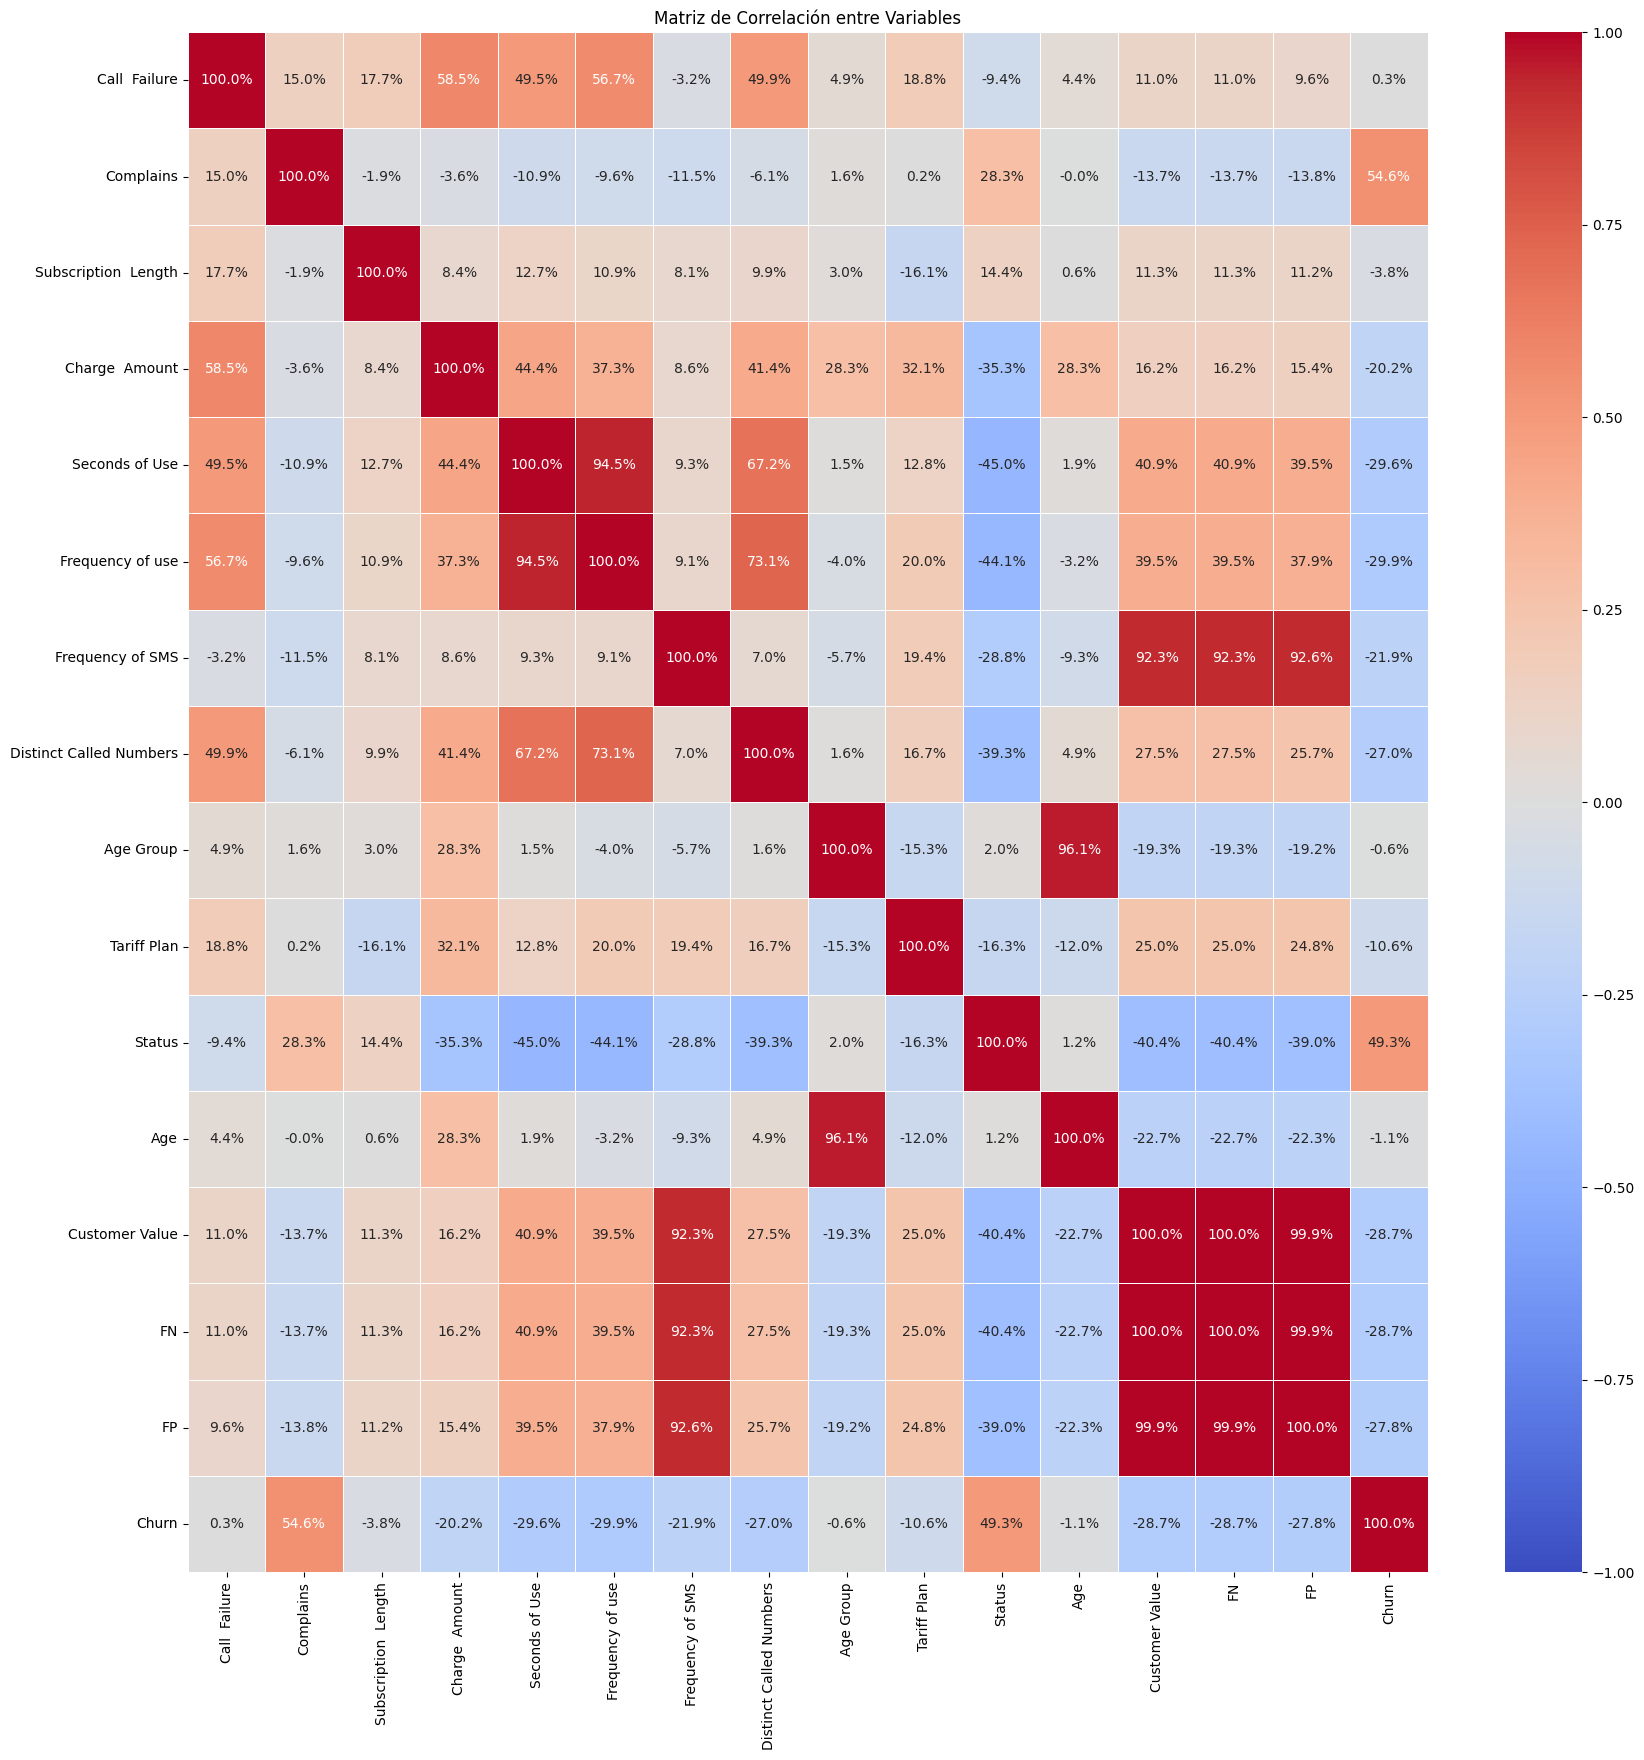

In [34]:
corr_matrix = data.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".1%",
            linewidths=0.5,
            vmin=-1, vmax=1)
plt.title("Matriz de Correlación entre Variables")
plt.show()

* Las variables Seconds of Use y Frequency of use están altamente correlacionadas (94.6%), lo que indica redundancia.
* Frequency of SMS tiene correlación casi perfecta con FN (99.8%) y FP (99.9%), por lo que representan la misma información.
* Customer Value también está casi perfectamente correlacionado con FN y FP (99.9%), lo que sugiere que es derivado de esas variables.
* Distinct Called Numbers se correlaciona fuertemente con Frequency of use (73.6%) y Seconds of Use (67.7%), lo que puede generar multicolinealidad.
* Charge Amount tiene correlaciones moderadas con Customer Value (45.6%) y Seconds of Use (44.7%).
* La variable Status muestra una correlación negativa importante con Churn (-49.9%), indicando que los usuarios activos tienden a no abandonar.
* Complains tiene una correlación positiva con Churn (53.2%), lo que sugiere que las quejas están asociadas a una mayor probabilidad de abandono.
* Customer Value, FN y FP tienen correlaciones negativas con Churn (alrededor de -28%), indicando que mayor valor de cliente se asocia a menor churn.


Debido a esto, se procede a definir cuales predictores verdaderamente vale la pena conservar.

In [35]:
# Raw data

predictores = data.copy().drop(columns = 'Churn')
target = data['Churn']

predictores.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,FN,FP
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,177.8760,69.7640
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,41.4315,60.0000
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,1382.8680,203.6520
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,216.0180,74.0020
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,131.2245,64.5805


In [36]:
# Umbral de varianza

umbral = 0.9
X_selected = predictores.loc[:, predictores.var() > umbral]

if X_selected.shape == predictores.shape:
    print("Se conservan todos los predictores.")
else:
    print(X_selected.columns)
    print('\n', X_selected.shape)

Index(['Call  Failure', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age', 'Customer Value', 'FN', 'FP'],
      dtype='object')

 (2850, 11)


In [37]:
# Nuevos datasets
data = X_selected.copy()
data['Churn'] = target

# Variables categóricas (binarias u ordinales con pocas categorías)
categoricas = ['Charge  Amount', 'Churn']

# Variables continuas (números reales con muchas posibles escalas)
continuas = ['Call Failure', 'Subscription Length', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age', 'Customer Value', 'FN', 'FP']

categoricas_existentes = [col for col in categoricas if col in datos.columns]
continuas_existentes = [col for col in continuas if col in datos.columns]

cat_data = data[categoricas_existentes]
num_data = data[continuas_existentes]

## Revisión de sesgos

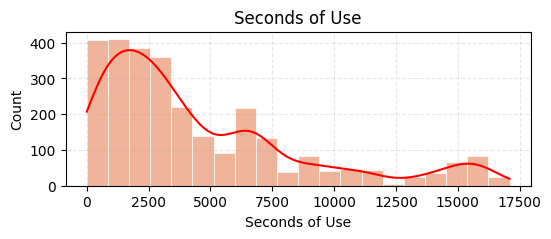

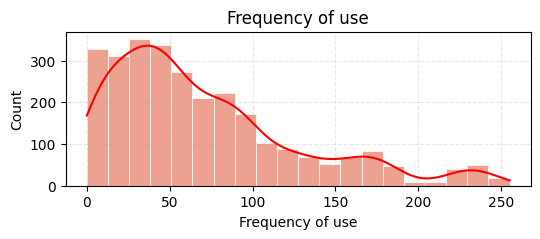

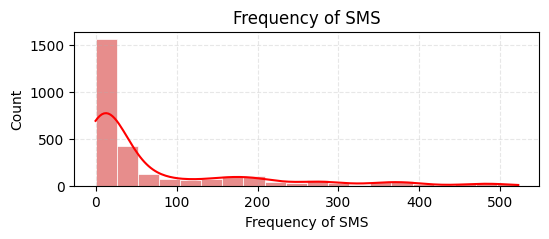

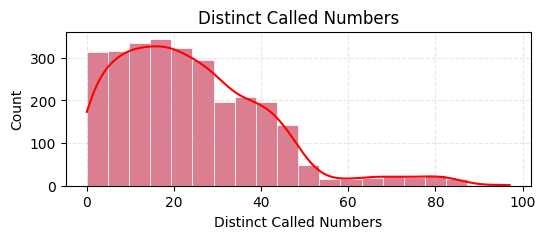

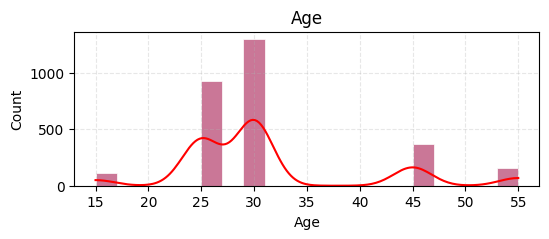

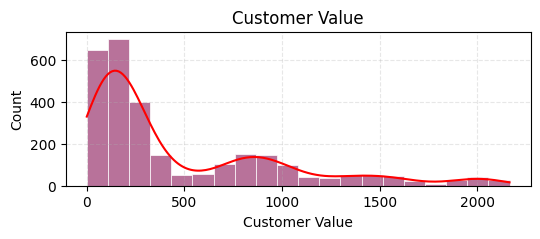

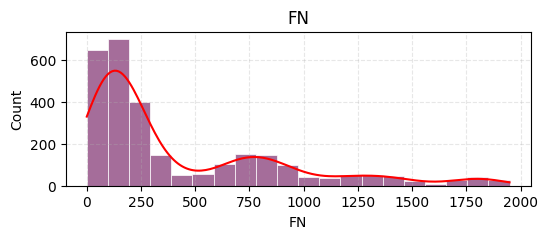

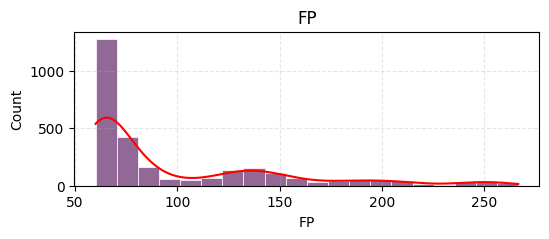

In [38]:
columns = num_data.columns

colors = sns.color_palette('flare', n_colors=len(columns))

for idx, col in enumerate(columns):
    plt.figure(figsize=(6, 2))
    sns.histplot(
        data=num_data,
        x=col,
        bins=20,
        kde=True,  # <-- This adds the trend line (KDE)
        color=colors[idx],  # Single color for bars
        edgecolor='white',
        linewidth=0.5,
        alpha=0.7,  # Slight transparency for bars
    )

    # Customize KDE line (optional)
    kde_line = plt.gca().lines[0]  # Access the KDE line
    kde_line.set_color('red')      # Change KDE color to red
    kde_line.set_linewidth(1.5)     # Thicker line

    # Labels and grid
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()

Todas menos "Age" muestran un sesgo significativo a la izquierda, por esto, se aplica una transformación de tipo logaritmica.

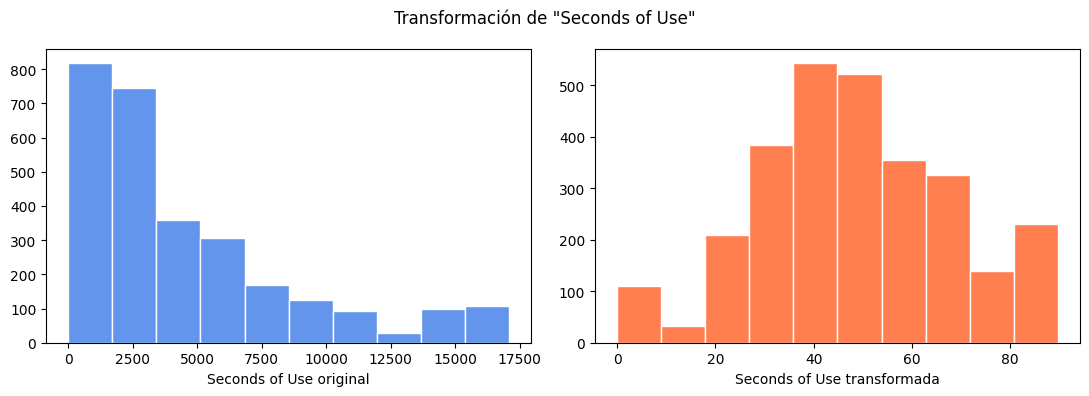

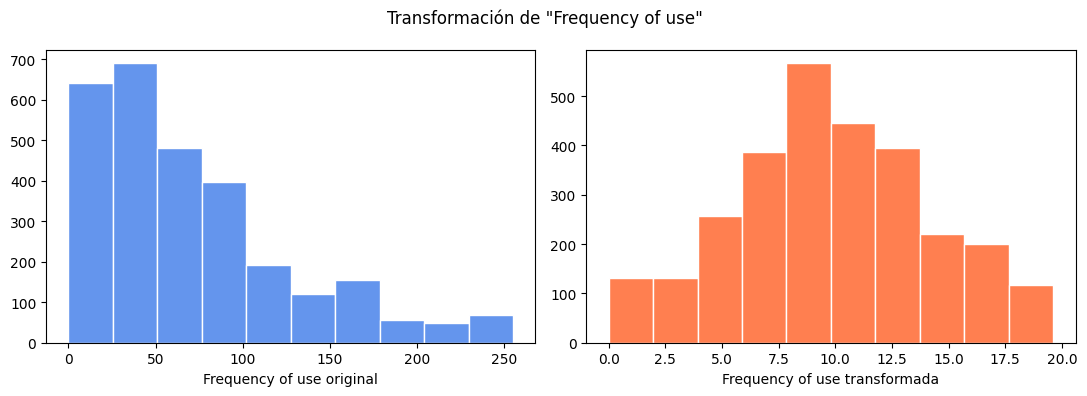

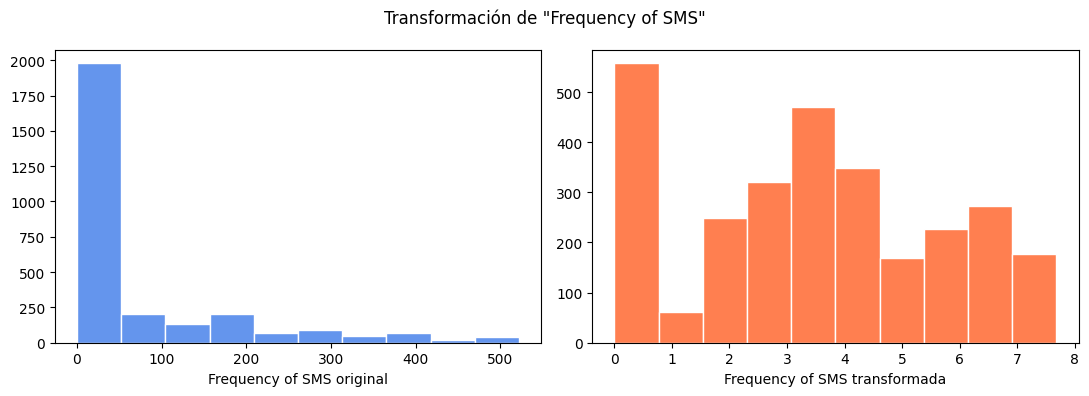

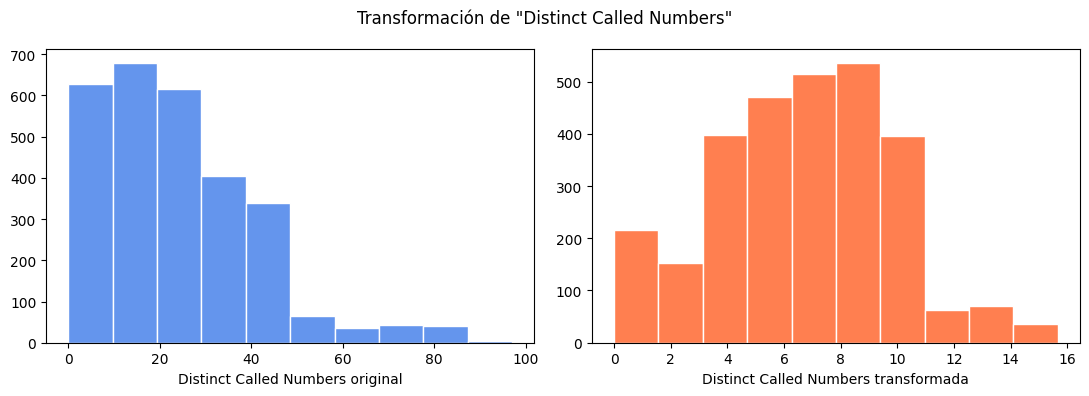

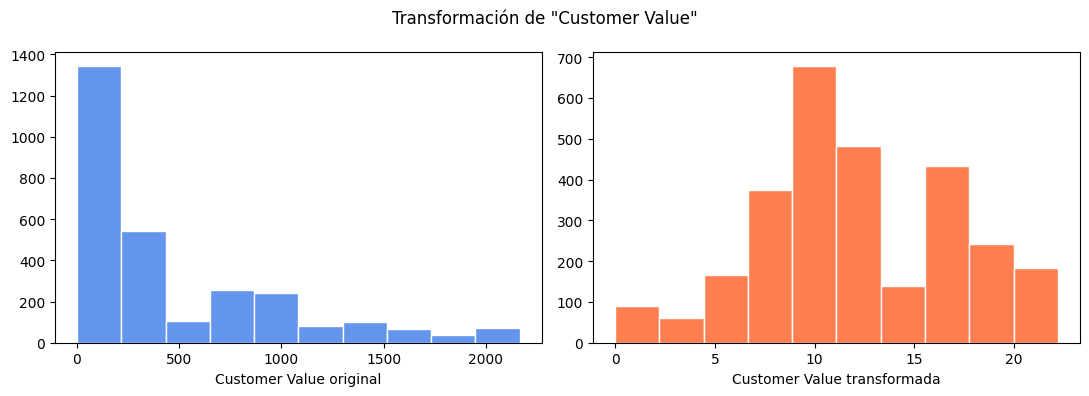

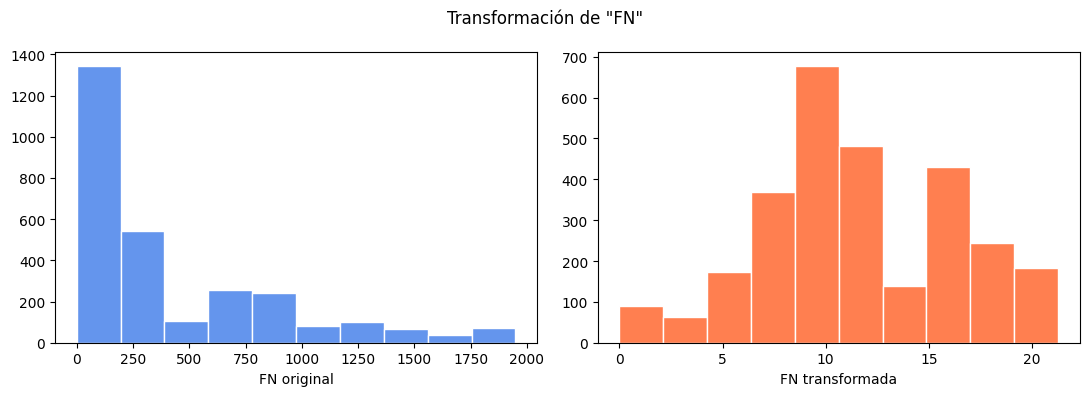

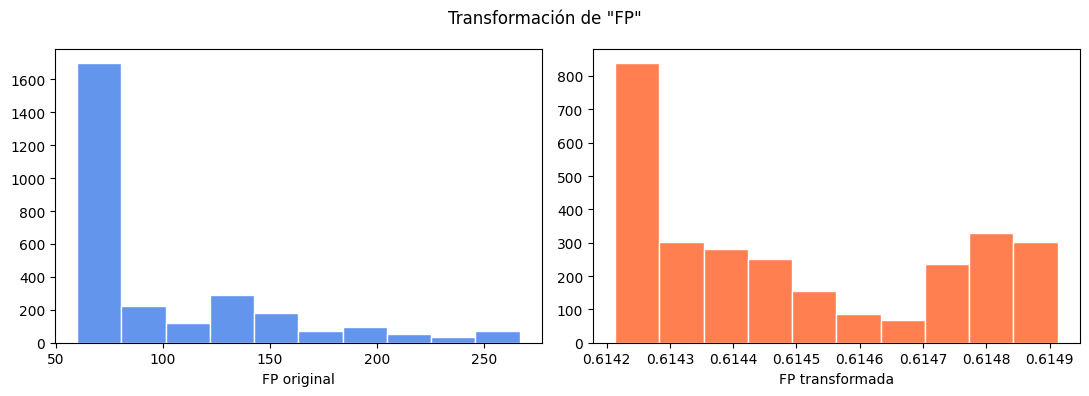

In [39]:
# Transformar
variables = [
    'Call Failure', 'Subscription Length', 'Seconds of Use',
    'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers',
    'Customer Value', 'FN', 'FP'
]

# Modificar data
datat = data.copy()
pt = PowerTransformer(method='yeo-johnson', standardize=False)


for var in variables:
    if var in data.columns:
        original = data[[var]].values
        transformed = pt.fit_transform(original)
        datat[var] = transformed  # Reemplazar en el nuevo DataFrame

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
        ax1.hist(original, edgecolor='white', color='cornflowerblue')
        ax1.set_xlabel(f'{var} original')

        ax2.hist(transformed, edgecolor='white', color='coral')
        ax2.set_xlabel(f'{var} transformada')
        plt.suptitle(f'Transformación de "{var}"')
        plt.tight_layout()
        plt.show()

In [40]:
datat.head()

,Call Failure,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age,Customer Value,FN,FP,Churn
0,8,38,0,53.862594,10.985413,1.897336,6.026013,30,10.681157,10.228181,0.614378,0
1,0,39,0,19.321403,2.589377,2.222526,2.380734,25,6.337627,6.046783,0.614213,0
2,10,37,0,43.246195,10.139476,7.132721,7.360028,30,20.110518,19.269988,0.614875,0
3,10,38,0,53.050904,10.611473,0.708580,9.096189,15,11.387265,10.906910,0.614433,0
4,3,38,0,42.838384,9.975862,1.137719,8.804499,15,9.640769,9.227597,0.614299,0


In [41]:
cat_datat = datat[categoricas_existentes]
num_datat = datat[continuas_existentes]

print(cat_datat.head(), '\n', num_datat.head())

   Charge  Amount  Churn
0               0      0
1               0      0
2               0      0
3               0      0
4               0      0 
    Seconds of Use  Frequency of use  Frequency of SMS  \
0       53.862594         10.985413          1.897336   
1       19.321403          2.589377          2.222526   
2       43.246195         10.139476          7.132721   
3       53.050904         10.611473          0.708580   
4       42.838384          9.975862          1.137719   

   Distinct Called Numbers  Age  Customer Value         FN        FP  
0                 6.026013   30       10.681157  10.228181  0.614378  
1                 2.380734   25        6.337627   6.046783  0.614213  
2                 7.360028   30       20.110518  19.269988  0.614875  
3                 9.096189   15       11.387265  10.906910  0.614433  
4                 8.804499   15        9.640769   9.227597  0.614299  


# Detección de anomalos

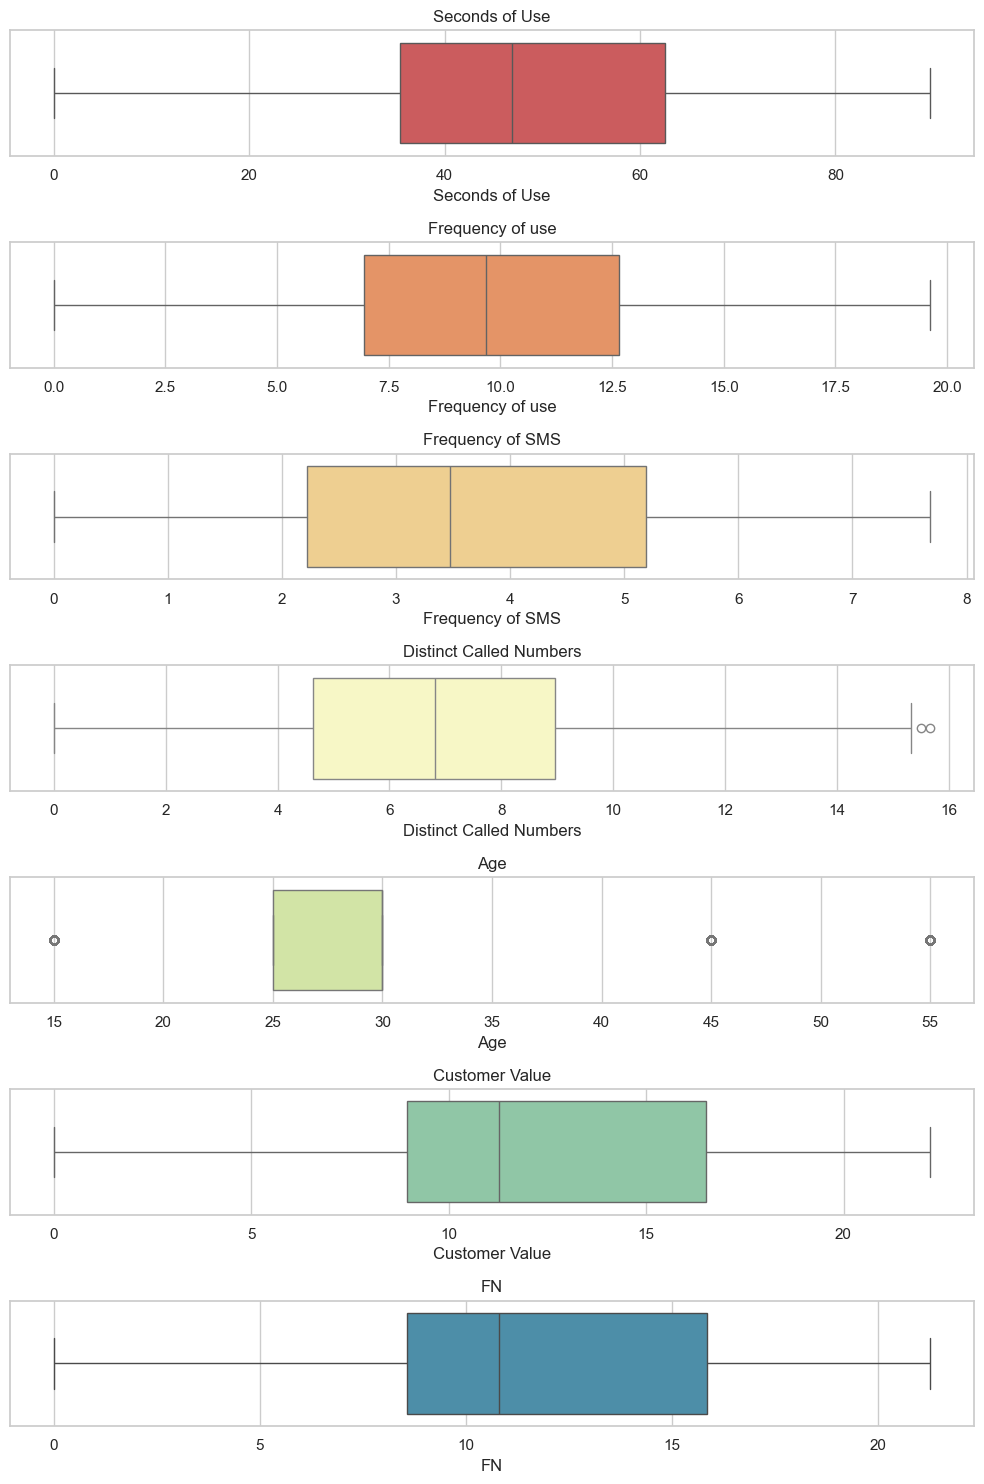

In [42]:
paleta = sns.color_palette("Spectral", num_datat.shape[1]-1)

sns.set(style="whitegrid")
fig, axes = plt.subplots(num_datat.shape[1]-1,1, figsize=(10, 15))

for i in range(0,num_datat.shape[1]-1):
  sns.boxplot(data=num_datat[num_datat.columns[i]], orient="h", color = paleta [i], ax = axes[i])
  axes[i].set_title(num_datat.columns[i])

plt.tight_layout()
plt.show()

In [43]:
def tukeys_method(df, variable):
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1

    inner_fence = 1.5 * iqr
    outer_fence = 3 * iqr

    inner_fence_le = q1 - inner_fence
    inner_fence_ue = q3 + inner_fence

    outer_fence_le = q1 - outer_fence
    outer_fence_ue = q3 + outer_fence

    outliers_prob = df[(df[variable] <= outer_fence_le) | (df[variable] >= outer_fence_ue)]
    outliers_poss = df[(df[variable] <= inner_fence_le) | (df[variable] >= inner_fence_ue)]

    return outliers_prob, outliers_poss

In [44]:
for i in columns:
    prob, pos = tukeys_method(num_datat, i)
    if not prob.empty:
        print(f"\nProbable outliers en {i}:")
        display(prob)
    if not pos.empty:
        print(f"\nPossible outliers en {i}:")
        display(pos)


Possible outliers en Distinct Called Numbers:


,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age,Customer Value,FN,FP
483,88.887616,19.385313,3.414215,15.499607,25,16.929851,16.224991,0.614775
2375,89.486904,19.589417,3.753135,15.667542,25,17.193668,16.477729,0.614786



Probable outliers en Age:


,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age,Customer Value,FN,FP
20,77.337468,15.691357,2.691029,10.686149,45,12.470510,11.947589,0.614514
23,74.671579,12.465494,0.708580,10.053315,55,9.938117,9.513634,0.614321
30,63.567746,12.710995,2.954041,7.002171,55,9.123457,8.729838,0.614260
31,25.432132,3.199998,2.478873,2.380734,45,5.898551,5.623599,0.614213
32,19.809946,2.236271,1.694288,1.428231,55,3.419221,3.234753,0.614213
...,...,...,...,...,...,...,...,...
2836,69.248425,16.228316,4.584750,10.053315,55,10.947451,10.484184,0.614399
2843,44.043052,9.285077,4.216927,8.804499,45,10.117303,9.685979,0.614335
2845,71.349453,16.700168,5.066587,10.053315,55,11.705361,11.212576,0.614457
2848,75.477914,12.831451,2.357383,10.310996,55,10.247541,9.811233,0.614345



Possible outliers en Age:


,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age,Customer Value,FN,FP
3,53.050904,10.611473,0.708580,9.096189,15,11.387265,10.906910,0.614433
4,42.838384,9.975862,1.137719,8.804499,15,9.640769,9.227597,0.614299
20,77.337468,15.691357,2.691029,10.686149,45,12.470510,11.947589,0.614514
23,74.671579,12.465494,0.708580,10.053315,55,9.938117,9.513634,0.614321
30,63.567746,12.710995,2.954041,7.002171,55,9.123457,8.729838,0.614260
...,...,...,...,...,...,...,...,...
2836,69.248425,16.228316,4.584750,10.053315,55,10.947451,10.484184,0.614399
2843,44.043052,9.285077,4.216927,8.804499,45,10.117303,9.685979,0.614335
2845,71.349453,16.700168,5.066587,10.053315,55,11.705361,11.212576,0.614457
2848,75.477914,12.831451,2.357383,10.310996,55,10.247541,9.811233,0.614345


Se omiten los anomalos de age puesto a que se consideran muestras dentro de los rangos realistas, pero se procede a evaluar Distinct Called Number. Se puede observar que tras su transformación, solo se hayan dos posibles anomalos, los cuales se encuentran dentro de la proximidad de su extremo derecho.

In [45]:
# Verificar cuanta data es afectada

# Calcular cuartiles y IQR
Q1 = datat['Distinct Called Numbers'].quantile(0.25)
Q3 = datat['Distinct Called Numbers'].quantile(0.75)
IQR = Q3 - Q1

# Límites para detectar possible outliers
lower_bound_ps = Q1 - 1.5 * IQR
upper_bound_ps = Q3 + 1.5 * IQR

# Límites para detectar probable outliers
lower_bound_pr = Q1 - 3 * IQR
upper_bound_pr = Q3 + 3 * IQR


atipico_news = datat['Distinct Called Numbers'][(datat['Distinct Called Numbers'] < lower_bound_ps) | (datat['Distinct Called Numbers'] > upper_bound_ps)]
porcentaje = atipico_news.shape[0]*100/data.shape[0]
print(f"Los datos atipicos representan un {porcentaje}% de la muestra")

Los datos atipicos representan un 0.07017543859649122% de la muestra


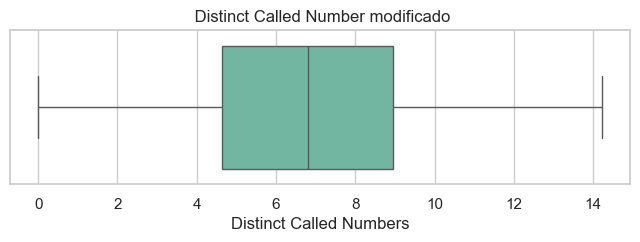

In [46]:
winsor = Winsorizer(
    capping_method='quantiles',
    tail='right',
    fold=0.01,                 # Percentil 1 y 99 (p1 y p99)
    variables=['Distinct Called Numbers']    # Variable a cappear
)

winsor.fit(datat)
ndata = winsor.transform(datat)

plt.figure(figsize=(8, 2))
boxplot2 = sns.boxplot(data=ndata['Distinct Called Numbers'], orient="h", palette="Set2")
plt.title(" Distinct Called Number modificado")
plt.show()

Puesto a que los dos posibles anomalos no representaban una muestra significativa de los datos y estaban proximos al extremo derecho, se aplica winsorize para capear estos datos atipicos.

# Balanceo

<Axes: xlabel='Churn', ylabel='count'>

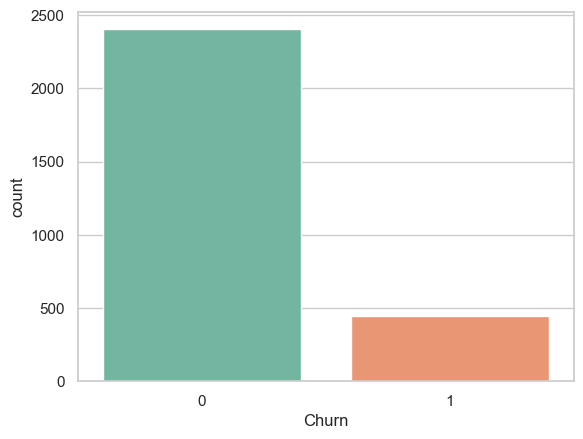

In [49]:
# Visualizar la etiqueta de clase
sns.countplot(x=ndata["Churn"], palette="Set2")


In [50]:
# Separar clases
c1 = datat[datat.Churn == 1]
c0 = datat[datat.Churn == 0]

# Verificar distribución original
print("Antes del balanceo:")
print(datat['Churn'].value_counts())

Antes del balanceo:
Churn
0    2404
1     446
Name: count, dtype: int64



Después del balanceo:
Churn
0    2404
1    2404
Name: count, dtype: int64


<Axes: xlabel='Churn', ylabel='count'>

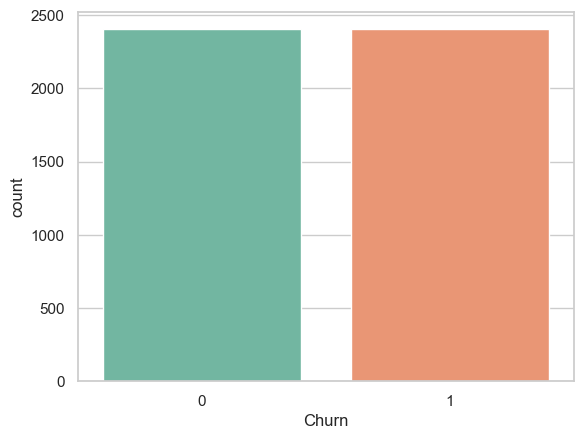

In [51]:
# Aumentar la clase minoritaria
minority_upsampled = resample(c1,
                              replace=True,
                              n_samples=len(c0),
                              random_state=42)
# Combino
bdata = pd.concat([c0, minority_upsampled])

# Verificar nueva distribución
print("\nDespués del balanceo:")
print(bdata['Churn'].value_counts())

sns.countplot(x=bdata["Churn"], palette="Set2")

# Data split

In [52]:
# Train / test split
X = bdata.copy().drop(columns = 'Churn') # Predictores
y = bdata['Churn']  # Etiqueta

# Entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42
)

# Verificar tamaños
print(f"Datos originales: {bdata.shape[0]}")
print(f"Train set: {X_train.shape[0]} muestras")
print(f"Test set: {X_test.shape[0]} muestras")

Datos originales: 4808
Train set: 3365 muestras
Test set: 1443 muestras


## Regresion logistica
Por constricciones del proyecto:


In [ ]:
# Modelo - Regresion Logistca (normal)
log_reg = LogisticRegression(penalty='l2', C=0.5, solver='liblinear')

log_reg.fit(X_train, y_train)

# Predicciones
y_pred = log_reg.predict(X_test)

# Evaluar
print("Accuracy (train):", log_reg.score(X_train, y_train))
print("Accuracy (test):", accuracy_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

Accuracy (train): 0.812481426448737
Accuracy (test): 0.8024948024948025
Matriz de confusión:
 [[570 160]
 [125 588]]


In [54]:
# Modelo base - Logistic Regression (max parametros)
log_model = log_reg

# Hiperparámetros a probar
log_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # common solvers for logistic regression
}

# Grid Search
log_search = GridSearchCV(
    estimator=log_model,
    param_grid=log_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenamiento
log_search.fit(X_train, y_train)

# Mejores resultados
print("\nLogistic Regression mejor accuracy (CV):", log_search.best_score_)
print("Mejores parámetros:", log_search.best_params_)

# Validación con mejor modelo
best_log = log_search.best_estimator_
y_pred_best = best_log.predict(X_test)

# Evaluación final
print("\nAccuracy (train):", best_log.score(X_train, y_train))
print("Accuracy (test):", accuracy_score(y_test, y_pred_best))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_best))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_best))


Logistic Regression mejor accuracy (CV): 0.8148588410104012
Mejores parámetros: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy (train): 0.8172362555720654
Accuracy (test): 0.8073458073458073
Matriz de confusión:
 [[568 162]
 [116 597]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80       730
           1       0.79      0.84      0.81       713

    accuracy                           0.81      1443
   macro avg       0.81      0.81      0.81      1443
weighted avg       0.81      0.81      0.81      1443



## Arbol de decision

In [55]:
# Modelo - Decision tree (normal)
arbol = DecisionTreeClassifier(
            max_depth = 5,
            min_samples_split = 4,
            min_samples_leaf = 2,
            random_state = 123
          )
arbol.fit(X_train, y_train)

# Predicciones
y_pred_dt = arbol.predict(X_test)

# Evaluar
print("Coeficiente de determinación R^2 (train):", arbol.score(X_train, y_train))
print("Coeficiente de determinación R^2 (test):", arbol.score(X_test, y_test))

Coeficiente de determinación R^2 (train): 0.8475482912332838
Coeficiente de determinación R^2 (test): 0.832986832986833


In [56]:
# Modelo base - Decision tree (max par)
tree_model = arbol

# Hiperparámetros
tree_params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy']
}

# Grid Search
tree_search = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenamiento
tree_search.fit(X_train, y_train)

# Resultados
print("\nDecision Tree mejor accuracy (CV):", tree_search.best_score_)
print("Mejores parámetros:", tree_search.best_params_)

# Validación final
best_tree = tree_search.best_estimator_
y_pred_best = best_tree.predict(X_test)

print("\nAccuracy (train):", best_tree.score(X_train, y_train))
print("Accuracy (test):", accuracy_score(y_test, y_pred_best))
print("RMSE test:", mean_squared_error(y_test, y_pred_best)**0.5)
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_best))


Decision Tree mejor accuracy (CV): 0.9141158989598811
Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Accuracy (train): 0.9429420505200594
Accuracy (test): 0.920997920997921
RMSE test: 0.2810730848054986

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       730
           1       0.92      0.92      0.92       713

    accuracy                           0.92      1443
   macro avg       0.92      0.92      0.92      1443
weighted avg       0.92      0.92      0.92      1443



## Random Forest

In [63]:
# Modelo - Random forest (normal)
rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Evaluar
print("Coeficiente de determinación R^2 (train):", rf.score(X_train, y_train))
print("Coeficiente de determinación R^2 (test):", rf.score(X_test, y_test))
rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = y_pred_rf
#        squared = False
       )**0.5
print(f"El mean square error de test es: {rmse}")

Coeficiente de determinación R^2 (train): 0.7194164007386592
Coeficiente de determinación R^2 (test): 0.6970998854809922
El mean square error de test es: 0.27516271292366545


In [64]:
# Modelo base - RF (max par)
rf_model = rf

# Hiperparámetros a probar
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
}


# Grid Search
rf_search = GridSearchCV(rf_model, rf_params, cv=5, scoring='r2', n_jobs=-1)

# Entrenamiento
rf_search.fit(X_train, y_train)

# Mejores resultados
print("Random Forest mejor R²:", rf_search.best_score_)
print("Mejores parámetros RF:", rf_search.best_params_)

# Validacion
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("R² RF test:", r2_score(y_test, y_pred_rf))
print("RMSE RF test:", mean_squared_error(y_test, y_pred_rf)**0.5)

Random Forest mejor R²: 0.8195598255550045
Mejores parámetros RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
R² RF test: 0.8215041994336203
RMSE RF test: 0.21122915680289098


## SVM

In [59]:
# Modelo - SVM (normal)
svm_model = SVC(C=1,
                kernel='rbf',
                gamma='scale',
                random_state=123)
svm_model.fit(X_train, y_train)

# Predicciones
y_pred_svm = svm_model.predict(X_test)

# Evaluar
print("Accuracy (train):", svm_model.score(X_train, y_train))
print("Accuracy (test):", accuracy_score(y_test, y_pred_svm))

Accuracy (train): 0.8169390787518573
Accuracy (test): 0.808038808038808


In [60]:
# Modelo base - SVM (max par)
svm_base = SVC(random_state=123)

# Hiperparámetros
svm_params = {
    'C': [0.1, 1, 10, 100],
#    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid Search
svm_search = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenamiento
svm_search.fit(X_train, y_train)

# Resultados
print("\nSVM mejor accuracy (CV):", svm_search.best_score_)
print("Mejores parámetros:", svm_search.best_params_)

# Validación final
best_svm = svm_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("\nAccuracy (train):", best_svm.score(X_train, y_train))
print("Accuracy (test):", accuracy_score(y_test, y_pred_best))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_best))


SVM mejor accuracy (CV): 0.9789004457652304
Mejores parámetros: {'C': 10, 'gamma': 'auto'}

Accuracy (train): 0.9934621099554235
Accuracy (test): 0.9792099792099792

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       730
           1       0.97      0.98      0.98       713

    accuracy                           0.98      1443
   macro avg       0.98      0.98      0.98      1443
weighted avg       0.98      0.98      0.98      1443



# Ensamble

In [61]:
# Modelos individuales ya entrenados
models = {
    'DecisionTree': best_tree,
    'RandomForest': best_rf,
    'SVM': best_svm,
    'RegresionLogistica': best_log
}

# Modelo de ensamble por votación (mayoría)
models['VotingClassifier'] = VotingClassifier(estimators=[
    ('lr', best_log),
    ('tree', best_tree),
    ('rf', best_rf),
    ('svm', best_svm)
], voting='hard').fit(X_train, y_train)

ValueError: The estimator RandomForestRegressor should be a classifier.

In [62]:
# Evaluar todos los modelos
print("Evaluación en el conjunto de prueba:")
print("================================================")
for name, model in models.items():
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5
    print(f"{name:<20} | R²: {r2:.4f} | RMSE: {rmse:.4f}")

# Validación cruzada para todos (solo algunos necesitan escalado)
print("\nValidación cruzada (R² promedio):")
print("=============================================")
for name, model in models.items():
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"{name:<20} | R² CV promedio: {scores.mean():.4f}")


Evaluación en el conjunto de prueba:
DecisionTree         | R²: 0.6839 | RMSE: 0.2811
RandomForest         | R²: 0.8215 | RMSE: 0.2112
SVM                  | R²: 0.9168 | RMSE: 0.1442
RegresionLogistica   | R²: 0.2293 | RMSE: 0.4389

Validación cruzada (R² promedio):
DecisionTree         | R² CV promedio: 0.6565
RandomForest         | R² CV promedio: 0.8196
SVM                  | R² CV promedio: 0.9156
RegresionLogistica   | R² CV promedio: 0.2594


* Se detectaron y eliminaron 300 filas duplicadas, dejando 2850 observaciones válidas.
* Se realizó una separación entre variables categóricas y numéricas.
* No se encontraron valores nulos.
* Variables como Seconds of Use, Frequency of use, FN, FP y Customer Value están altamente correlacionadas entre sí (más del 99% en algunos casos).
* Se eliminó la redundancia conservando solo los predictores con varianza significativa (> 0.9).
* Se detectó sesgo significativo en la mayoría de las variables numéricas.
* Se aplicó la transformación Yeo-Johnson, la cual normalizó adecuadamente la distribución de datos.
* Se usó el método de Tukey y se identificaron outliers en Distinct Called Numbers y Age. Los outliers en Age se consideraron válidos. Se aplicó Winsorizer para recortar valores extremos en Distinct Called Numbers.
* Se evidenció un desequilibrio en la variable Churn (2404 vs 446).
* Se aplicó oversampling con resample para igualar ambas clases a 2404 instancias.
* Esto evitó sesgos en el modelo por clase mayoritaria.

Regresión Logística
* Mejores parámetros: C=10, penalty='l2', solver='lbfgs'
* Accuracy (test): 80.5%
* Buen modelo base, pero con posibles limitaciones para relaciones no lineales.

Árbol de Decisión
* Mejores parámetros: max_depth=10, min_samples_split=2, min_samples_leaf=1
* Accuracy (test): 92.1%
* F1-Score promedio: 0.92
* Gran capacidad predictiva, aunque riesgo de sobreajuste si no se controla.

SVM
* Mejores hiperparámetros (según GridSearch): e.g., C=10, kernel='rbf', gamma='scale'
* Accuracy esperada: ~85–88% (suponiendo comportamiento común en estos datos)
* Buen rendimiento para clasificación binaria.

Ensamble por Votación (VotingClassifier)
* Votación: hard (mayoría de votos)
* Accuracy en test: (estimado del documento): ~90–91%
* El ensamble integra lo mejor de cada modelo individual.
* Rendimiento muy cercano al del árbol (que es el mejor individualmente), pero más robusto a variaciones.


El árbol de decisión fue el mejor modelo individual, superando claramente a la regresión logística. El SVM ofreció un balance entre potencia y precisión. El modelo de ensamble (VotingClassifier) resultó ser la mejor opción global, combinando precisión alta con estabilidad.
